# TAHAP 5

### Subbab 5.1 — Konfigurasi path dan parameter

Mengatur path, parameter, dan variabel penting sebelum proses dijalankan.


In [30]:
import os
import re
import pandas as pd

# --- Konfigurasi Path ---
BASE_DRIVE_PATH = ".." # Changed from colab path to local relative path
PATH_PROCESSED = os.path.join(BASE_DRIVE_PATH, "data/processed")
PROCESSED_CSV_FILENAME = "cases_processed.csv"
processed_data_filepath = os.path.join(PATH_PROCESSED, PROCESSED_CSV_FILENAME)

# --- Verifikasi kolom amar_kategori (sudah dibuat di Tahap 2) ---
# amar_kategori dibuat otomatis di Tahap 2 sehingga tersedia untuk Tahap 4 & 5.
# Sel ini hanya memverifikasi dan menampilkan distribusinya.
try:
    df_verify = pd.read_csv(processed_data_filepath)
    if 'amar_kategori' in df_verify.columns:
        print('✅ Kolom amar_kategori sudah ada di cases_processed.csv')
        print('\nDistribusi amar_kategori:')
        print(df_verify['amar_kategori'].value_counts().to_string())
        display(df_verify[['case_id', 'amar_putusan', 'amar_kategori']].head(10))
    else:
        # Fallback: buat sekarang jika belum ada (misal Tahap 2 dijalankan versi lama)
        print('⚠️  amar_kategori belum ada. Membuat sekarang...')
        def get_kategori_amar(full_text):
            if pd.isna(full_text) or not isinstance(full_text, str):
                return 'Teks Tidak Valid'
            m = re.search(
                r'MENGADILI,?\s*(.*?)(Demikianlah diputuskan|Memperhatikan pasal-pasal)',
                full_text, re.IGNORECASE | re.DOTALL
            )
            if not m:
                return 'Amar Tidak Ditemukan'
            t = m.group(1).lower()
            if 'menolak permohonan' in t:
                return 'Menolak permohonan'
            elif 'mengabulkan seluruhnya' in t or 'mengabulkan permohonan banding' in t:
                return 'Mengabulkan seluruhnya'
            elif 'mengabulkan sebagian' in t:
                return 'Mengabulkan sebagian'
            elif 'tidak dapat diterima' in t:
                return 'Tidak dapat diterima'
            else:
                return 'Lain-lain (Perlu Cek Manual)'

        text_col = 'text_full' if 'text_full' in df_verify.columns else 'full_text_putusan'
        df_verify['amar_kategori'] = df_verify[text_col].apply(get_kategori_amar)
        df_verify.to_csv(processed_data_filepath, index=False, encoding='utf-8')
        print('✅ amar_kategori berhasil dibuat dan disimpan.')
        print(df_verify['amar_kategori'].value_counts().to_string())
        display(df_verify[['case_id', 'amar_putusan', 'amar_kategori']].head(10))
except FileNotFoundError:
    print(f'❌ File tidak ditemukan: {processed_data_filepath}')
    print('Pastikan Tahap 2 sudah dijalankan.')
except Exception as e:
    print(f'❌ Error: {e}')


✅ Kolom amar_kategori sudah ada di cases_processed.csv

Distribusi amar_kategori:
amar_kategori
Menolak permohonan              34
Mengabulkan seluruhnya           4
Lain-lain (Perlu Cek Manual)     3
Tidak dapat diterima             1
Mengabulkan sebagian             1


,case_id,amar_putusan,amar_kategori
0,case_001,kembali perkara ini dengan amar sebagaimana ya...,Lain-lain (Perlu Cek Manual)
1,case_002,Menolak permohonan peninjauan kembali dari Pem...,Menolak permohonan
2,case_003,Menolak permohonan peninjauan kembali dari Pem...,Menolak permohonan
3,case_004,Menolak permohonan peninjauan kembali dari Pem...,Menolak permohonan
4,case_005,:1.Menolak permohonan peninjauan kembali dari ...,Menolak permohonan
5,case_006,Menolak permohonan peninjauan kembali dari Pem...,Menolak permohonan
6,case_007,Menolak gugatan Penggugat terhadap Keputusan T...,Menolak permohonan
7,case_008,sendiri: 3.1. Menolak permohonan gugatan Termo...,Menolak permohonan
8,case_009,sendiri:3. 1.Menolak permohonan banding Termoh...,Menolak permohonan
9,case_010,SENDIRI:1.Membatalkan Surat Keputusan Direktur...,Menolak permohonan


### Subbab 5.2 — Import pustaka

Memuat library yang dibutuhkan untuk tahap ini.


In [31]:
# 05_Model_Evaluation.ipynb

import os
import pandas as pd
import numpy as np
import json
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# from google.colab import drive

### Subbab 5.3 — Konfigurasi path dan parameter

Mengatur path, parameter, dan variabel penting sebelum proses dijalankan.


In [32]:
# --- Bagian Konfigurasi ---
# !!! IMPORTANT: Ensure these path match your Google Drive structure
# dan output dari notebook sebelumnya !!!
BASE_DRIVE_PATH = ".." # Changed from colab path to local relative path

# Path untuk input data
PATH_EVAL_INPUT = os.path.join(BASE_DRIVE_PATH, "data/eval")
QUERIES_JSON_FILENAME = "queries.json" # Contains ground_truth_ids for retrieval

PATH_RESULTS_INPUT = os.path.join(BASE_DRIVE_PATH, "data/results")
PREDICTIONS_CSV_FILENAME = "predictions.csv" # Contains retrieved top_k_ids and predicted_solutions

PATH_PROCESSED_INPUT = os.path.join(BASE_DRIVE_PATH, "data/processed") # For actual case data if needed
PROCESSED_CSV_FILENAME = "cases_processed.csv"


# Path untuk output metrics
PATH_EVAL_OUTPUT = os.path.join(BASE_DRIVE_PATH, "data/eval") # Outputting metrics here too
RETRIEVAL_METRICS_FILENAME = "retrieval_metrics.csv"
PREDICTION_METRICS_FILENAME = "prediction_metrics.csv"

# K value untuk retrieval evaluation (e.g., evaluate Precision@K, Recall@K)
K_EVAL = 5 # Should match the 'k' used for generating top_k_case_ids in predictions.csv

### Subbab 5.4 — Fungsi bantu

Berisi fungsi utilitas yang dipakai ulang pada proses inti.


In [33]:
def load_data_for_evaluation():
    log_cleaning_action("[Tahap 5] Loading data untuk evaluasi...")
    """Memuat query, prediksi, dan kasus terproses."""
    global df_queries, df_predictions, df_cases
    queries_json_filepath    = os.path.join(PATH_EVAL_INPUT, QUERIES_JSON_FILENAME)
    predictions_csv_filepath = os.path.join(PATH_RESULTS_INPUT, PREDICTIONS_CSV_FILENAME)
    cases_csv_filepath       = os.path.join(PATH_PROCESSED_INPUT, PROCESSED_CSV_FILENAME)

    # ── Muat queries.json ──
    try:
        with open(queries_json_filepath, 'r', encoding='utf-8') as f:
            queries_data_list = json.load(f)
        df_queries = pd.DataFrame(queries_data_list)

        # ground_truth_ids: pastikan selalu list
        df_queries['ground_truth_ids'] = df_queries['ground_truth_ids'].apply(
            lambda x: x if isinstance(x, list) else []
        )

        # ground_truth_solution: bersihkan nilai kosong/NaN
        if 'ground_truth_solution' in df_queries.columns:
            df_queries['ground_truth_solution'] = df_queries['ground_truth_solution'].apply(
                lambda x: str(x).strip()
                if pd.notna(x) and str(x).strip() not in ['', 'nan', 'None']
                else np.nan
            )
            valid_gt = df_queries['ground_truth_solution'].notna().sum()
            print(f"Loaded queries: {len(df_queries)} total, "
                  f"{valid_gt} dengan ground_truth_solution valid.")
            if valid_gt > 0:
                print("Distribusi ground_truth_solution:")
                print(df_queries['ground_truth_solution'].value_counts().to_string())
        else:
            print(f"Loaded queries: {len(df_queries)} (tanpa ground_truth_solution)")

    except FileNotFoundError:
        print(f"Error: queries.json tidak ditemukan di {queries_json_filepath}.")
        return False
    except Exception as e:
        print(f"Error loading queries.json: {e}")
        return False

    # ── Muat predictions.csv ──
    try:
        df_predictions = pd.read_csv(predictions_csv_filepath)
        df_predictions['top_k_case_ids_list'] = df_predictions['top_5_case_ids'].apply(
            lambda x: [c.strip() for c in str(x).split(',') if c.strip()]
            if pd.notna(x) and str(x).strip() else []
        )
        # Normalisasi predicted_solution: potong whitespace & karakter aneh
        df_predictions['predicted_solution'] = df_predictions['predicted_solution'].apply(
            lambda x: str(x).strip() if pd.notna(x) else ''
        )
        print(f"\nLoaded predictions: {len(df_predictions)} baris.")
        print("Distribusi predicted_solution:")
        print(df_predictions['predicted_solution'].value_counts().head(10).to_string())
    except FileNotFoundError:
        print(f"Error: predictions.csv tidak ditemukan di {predictions_csv_filepath}.")
        return False
    except Exception as e:
        print(f"Error loading predictions.csv: {e}")
        return False

    # ── Muat cases_processed.csv ──
    try:
        df_cases = pd.read_csv(cases_csv_filepath)
        print(f"\nLoaded cases: {len(df_cases)} kasus.")
    except FileNotFoundError:
        print(f"Warning: cases_processed.csv tidak ditemukan.")
        df_cases = None
    except Exception as e:
        print(f"Error loading cases: {e}")
        df_cases = None

    log_cleaning_action("[Tahap 5] Semua data evaluasi berhasil dimuat.")
    return True


### Subbab 5.5 — Definisi fungsi `evaluate_retrieval_performance`

Mendefinisikan fungsi `evaluate_retrieval_performance` untuk kebutuhan proses pada tahap ini.


In [34]:
import numpy as np
# --- Tahap 5.a: Evaluasi Retrieval ---
def calculate_retrieval_metrics_for_query(retrieved_ids, ground_truth_ids):
    """
    Menghitung Precision, Recall, dan F1-Score untuk satu query.
    retrieved_ids: list of case_ids yang diambil oleh sistem
    ground_truth_ids: list of case_ids yang relevan (ground truth)
    """
    if not ground_truth_ids:
        # Jika tidak ada ground truth, metrik tidak terdefinisi atau 0.
        return 0.0, 0.0, 0.0

    retrieved_set = set(retrieved_ids)
    ground_truth_set = set(ground_truth_ids)

    # Intersection of retrieved and ground truth
    true_positives = len(retrieved_set.intersection(ground_truth_set))

    # Precision: TP / (TP + FP) = TP / (jumlah dokumen yang diambil)
    # Jika tidak ada yang diambil, precision 0
    precision = true_positives / len(retrieved_set) if retrieved_set else 0.0

    # Recall: TP / (TP + FN) = TP / (jumlah dokumen yang relevan)
    recall = true_positives / len(ground_truth_set) if ground_truth_set else 0.0

    # F1-Score: 2 * (Precision * Recall) / (Precision + Recall)
    if (precision + recall) == 0:
        f1_score = 0.0
    else:
        f1_score = 2 * (precision * recall) / (precision + recall)

    return precision, recall, f1_score

def evaluate_retrieval_performance():
    log_cleaning_action("[Tahap 5.a] Evaluating Retrieval Performance...")
    global df_queries, df_predictions
    print('\n--- Evaluating Retrieval Performance ---')

    eval_df = pd.merge(
        df_predictions,
        df_queries[['query_id', 'ground_truth_ids']],
        on='query_id', how='left'
    )

    # ── Cek apakah ground_truth_ids tersedia dan tidak semua kosong ──
    has_ground_truth = (
        'ground_truth_ids' in eval_df.columns
        and not eval_df['ground_truth_ids'].isnull().all()
        and eval_df['ground_truth_ids'].apply(
            lambda x: isinstance(x, list) and len(x) > 0
        ).any()
    )

    retrieval_metrics_log = []

    if has_ground_truth:
        # ── Mode normal: hitung precision/recall/F1 ──
        for _, row in eval_df.iterrows():
            retrieved_ids = row['top_k_case_ids_list'][:K_EVAL]
            ground_truth  = row['ground_truth_ids']
            if not isinstance(ground_truth, list) or not ground_truth:
                precision, recall, f1 = 0, 0, 0
            else:
                precision, recall, f1 = calculate_retrieval_metrics_for_query(retrieved_ids, ground_truth)
            retrieval_metrics_log.append({
                'query_id'                     : row['query_id'],
                'retrieval_method'             : row.get('retrieval_method', 'UNKNOWN'),
                'prediction_algorithm_context' : row.get('prediction_algorithm', 'UNKNOWN'),
                f'precision_at_{K_EVAL}'       : precision,
                f'recall_at_{K_EVAL}'          : recall,
                f'f1_score_at_{K_EVAL}'        : f1,
            })

        df_retrieval_metrics = pd.DataFrame(retrieval_metrics_log)
        filepath = os.path.join(PATH_EVAL_OUTPUT, 'retrieval_metrics_per_query.csv')
        df_retrieval_metrics.to_csv(filepath, index=False, encoding='utf-8')
        log_cleaning_action(f'[Tahap 5.a] Per-query retrieval metrics disimpan: {filepath}')
        print(f'Per-query retrieval metrics saved to: {filepath}')
        display(df_retrieval_metrics.head())

        cols_for_avg = [f'precision_at_{K_EVAL}', f'recall_at_{K_EVAL}', f'f1_score_at_{K_EVAL}']
        unique_events = df_retrieval_metrics.drop_duplicates(subset=['query_id', 'retrieval_method'])
        df_avg = unique_events.groupby('retrieval_method')[cols_for_avg].mean().reset_index()

        print('\nAverage Retrieval Metrics per Method:')
        display(df_avg)
        filepath_avg = os.path.join(PATH_EVAL_OUTPUT, RETRIEVAL_METRICS_FILENAME)
        df_avg.to_csv(filepath_avg, index=False, encoding='utf-8')
        log_cleaning_action(f'[Tahap 5.a] Average retrieval metrics disimpan: {filepath_avg}')
        print(f'Average retrieval metrics saved to: {filepath_avg}')
        return df_avg

    else:
        # ── Fallback: ground_truth_ids kosong → tampilkan similarity-score chart ──
        print()
        print('⚠️  ground_truth_ids di queries.json masih kosong ([]).')
        print('   Precision/Recall/F1 tidak dapat dihitung tanpa label ground truth.')
        print('   → Menampilkan grafik alternatif: Rata-rata Similarity Score per Query.\n')

        # Parsing similarity score dari kolom predicted_solution atau top_5_case_ids
        # Gunakan jumlah retrieved cases sebagai proxy keberagaman retrieval
        score_rows = []
        for _, row in df_predictions.iterrows():
            ids_str = str(row.get('top_5_case_ids', ''))
            ids_list = [x.strip() for x in ids_str.split(',') if x.strip()]
            score_rows.append({
                'query_id'           : row['query_id'],
                'retrieval_method'   : row.get('retrieval_method', 'tfidf'),
                'prediction_algorithm': row.get('prediction_algorithm', ''),
                'jumlah_retrieved'   : len(ids_list),
            })

        df_score = pd.DataFrame(score_rows)

        # Simpan dummy metrics agar file tersedia untuk tahap lain
        df_dummy = df_score.groupby('retrieval_method')['jumlah_retrieved'].mean().reset_index()
        df_dummy.columns = ['retrieval_method', f'avg_retrieved_docs_at_{K_EVAL}']
        # Tambahkan kolom dummy 0 agar kolom precision/recall/f1 tetap ada
        for col in [f'precision_at_{K_EVAL}', f'recall_at_{K_EVAL}', f'f1_score_at_{K_EVAL}']:
            df_dummy[col] = 0.0
        filepath_avg = os.path.join(PATH_EVAL_OUTPUT, RETRIEVAL_METRICS_FILENAME)
        df_dummy.to_csv(filepath_avg, index=False, encoding='utf-8')

        # ── Grafik 1: Jumlah dokumen berhasil di-retrieve per query ──
        import matplotlib.pyplot as plt
        import matplotlib.ticker as mticker

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle('Evaluasi Retrieval (Proxy) — Ground Truth Belum Diisi', fontsize=14, fontweight='bold')

        # Panel kiri: bar jumlah retrieved per query per metode
        pivot = df_score.pivot_table(
            index='query_id', columns='retrieval_method',
            values='jumlah_retrieved', aggfunc='first'
        )
        pivot.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='black')
        axes[0].set_title(f'Dokumen Ter-retrieve per Query (target K={K_EVAL})')
        axes[0].set_xlabel('Query ID')
        axes[0].set_ylabel('Jumlah Dokumen')
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
        axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        axes[0].legend(title='Metode')
        axes[0].axhline(K_EVAL, color='red', linestyle='--', linewidth=1, label=f'Target K={K_EVAL}')

        # Panel kanan: distribusi metode retrieval
        method_counts = df_score.groupby('retrieval_method')['jumlah_retrieved'].mean()
        method_counts.plot(kind='bar', ax=axes[1], color=['#2196F3', '#FF9800', '#4CAF50'][:len(method_counts)], edgecolor='black')
        axes[1].set_title('Rata-rata Dokumen Ter-retrieve per Metode')
        axes[1].set_xlabel('Metode Retrieval')
        axes[1].set_ylabel('Rata-rata Dokumen')
        axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
        axes[1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

        plt.tight_layout()
        chart_path = os.path.join(PATH_EVAL_OUTPUT, 'retrieval_performance_chart.png')
        plt.savefig(chart_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'✅ Grafik disimpan ke: {chart_path}')
        print()
        print('💡 Cara mengisi ground_truth_ids:')
        print('   Buka file data/eval/queries.json, lalu isi "ground_truth_ids" dengan')
        print('   daftar case_id (misal ["case_001","case_005"]) yang relevan untuk setiap query.')
        print('   Setelah diisi, jalankan ulang Tahap 5 untuk mendapatkan Precision/Recall/F1 yang akurat.')

        return df_dummy

### Subbab 5.6 — Definisi fungsi `evaluate_prediction_performance`

Mendefinisikan fungsi `evaluate_prediction_performance` untuk kebutuhan proses pada tahap ini.


In [35]:
# --- Tahap 5.b: Evaluasi Prediksi (Solution Reuse) ---
def evaluate_prediction_performance():
    log_cleaning_action("[Tahap 5.b] Evaluating Prediction Performance...")
    global df_queries, df_predictions, df_cases
    print('\n--- Evaluating Prediction (Solution Reuse) Performance ---')

    has_gt_solution = (
        'ground_truth_solution' in df_queries.columns
        and df_queries['ground_truth_solution'].notna().any()
    )

    if not has_gt_solution:
        # ── Fallback: visualisasi distribusi prediksi amar ──
        print()
        print("⚠️  'ground_truth_solution' belum ada di queries.json.")
        print('   Accuracy/F1 tidak dapat dihitung tanpa label ground truth solusi.')
        print('   → Menampilkan grafik alternatif: Distribusi Prediksi Amar Putusan.\n')

        import matplotlib.pyplot as plt
        import matplotlib.ticker as mticker

        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        fig.suptitle('Evaluasi Prediksi (Proxy) — Ground Truth Solusi Belum Diisi',
                     fontsize=13, fontweight='bold')

        # ── Panel kiri: distribusi prediksi per algoritma ──
        algos = df_predictions['prediction_algorithm'].unique()
        colors_map = {'majority_vote': '#2196F3', 'weighted_similarity': '#FF9800'}

        all_preds = df_predictions['predicted_solution'].dropna()
        pred_counts = all_preds.value_counts()

        if pred_counts.empty:
            axes[0].text(0.5, 0.5, 'Tidak ada prediksi valid',
                         ha='center', va='center', transform=axes[0].transAxes)
        else:
            bars = axes[0].barh(
                pred_counts.index.str[:40],  # truncate long labels
                pred_counts.values,
                color='#4CAF50', edgecolor='black'
            )
            axes[0].set_title('Distribusi Semua Prediksi Amar')
            axes[0].set_xlabel('Jumlah Prediksi')
            axes[0].set_ylabel('Kategori Amar')
            axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
            for bar in bars:
                axes[0].text(
                    bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                    f'{int(bar.get_width())}', va='center', fontsize=9
                )

        # ── Panel kanan: per-algoritma ──
        algo_pred_data = []
        for algo in algos:
            sub = df_predictions[df_predictions['prediction_algorithm'] == algo]
            counts = sub['predicted_solution'].value_counts()
            for cat, cnt in counts.items():
                algo_pred_data.append({'algorithm': algo, 'kategori_amar': str(cat)[:35], 'count': cnt})

        if algo_pred_data:
            df_algo = pd.DataFrame(algo_pred_data)
            pivot_algo = df_algo.pivot_table(
                index='kategori_amar', columns='algorithm', values='count', aggfunc='sum', fill_value=0
            )
            pivot_algo.plot(kind='bar', ax=axes[1],
                            color=[colors_map.get(c, '#9C27B0') for c in pivot_algo.columns],
                            edgecolor='black')
            axes[1].set_title('Distribusi Prediksi per Algoritma')
            axes[1].set_xlabel('Kategori Amar')
            axes[1].set_ylabel('Jumlah')
            axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
            axes[1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
            axes[1].legend(title='Algoritma')
        else:
            axes[1].text(0.5, 0.5, 'Tidak ada data prediksi',
                         ha='center', va='center', transform=axes[1].transAxes)

        plt.tight_layout()
        chart_path = os.path.join(PATH_EVAL_OUTPUT, 'prediction_performance_chart.png')
        plt.savefig(chart_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'✅ Grafik disimpan ke: {chart_path}')
        print()
        print('💡 Cara mengisi ground_truth_solution:')
        print('   Buka data/eval/queries.json, tambahkan field "ground_truth_solution" pada setiap query,')
        print('   misalnya: "ground_truth_solution": "Menolak permohonan"')
        print('   Nilai valid: Menolak permohonan | Mengabulkan seluruhnya |')
        print('                Mengabulkan sebagian | Tidak dapat diterima | Lain-lain')
        return pd.DataFrame()

    # ── Mode normal (jika ground_truth_solution tersedia) ──
    from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report

    eval_pred_df = pd.merge(
        df_predictions,
        df_queries[['query_id', 'ground_truth_solution']],
        on='query_id', how='left'
    )

    # Normalisasi kedua kolom sebelum dibandingkan
    def normalize_solution(s):
        if pd.isna(s): return ''
        s = str(s).strip().lower()
        # Mapping ke kategori standar
        if 'menolak' in s: return 'Menolak permohonan'
        if 'seluruh' in s or 'banding' in s: return 'Mengabulkan seluruhnya'
        if 'sebagian' in s: return 'Mengabulkan sebagian'
        if 'tidak dapat diterima' in s or 'niet ontvankelijk' in s: return 'Tidak dapat diterima'
        if s in ['', 'nan', 'none', 'solution_not_available',
                 'solution_not_found', 'no_solution_retrieved',
                 'amar tidak ditemukan', 'teks tidak valid']: return ''
        return 'Lain-lain (Perlu Cek Manual)'

    eval_pred_df['predicted_solution_norm'] = eval_pred_df['predicted_solution'].apply(normalize_solution)
    eval_pred_df['gt_solution_norm']        = eval_pred_df['ground_truth_solution'].apply(normalize_solution)

    # Hapus baris dengan salah satu nilai kosong setelah normalisasi
    eval_pred_df_valid = eval_pred_df[
        (eval_pred_df['predicted_solution_norm'] != '') &
        (eval_pred_df['gt_solution_norm'] != '')
    ].copy()

    print(f"\nEntri valid untuk evaluasi prediksi: {len(eval_pred_df_valid)}")
    if not eval_pred_df_valid.empty:
        print("\nSample perbandingan prediksi vs ground truth:")
        display(eval_pred_df_valid[['query_id','gt_solution_norm','predicted_solution_norm']].head(10))

    if eval_pred_df_valid.empty:
        print('Tidak ada entri valid dengan prediksi dan ground truth solusi.')
        return pd.DataFrame()

    prediction_metrics_log = []
    all_prediction_reports = {}

    for name, group in eval_pred_df_valid.groupby(['retrieval_method', 'prediction_algorithm']):
        group = group[group['gt_solution_norm'] != '']
        ret_method, pred_algo = name
        y_true = group['gt_solution_norm']
        y_pred = group['predicted_solution_norm']
        if len(y_true) == 0:
            continue
        accuracy = accuracy_score(y_true, y_pred)
        p_mac, r_mac, f1_mac, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
        p_w, r_w, f1_w, _       = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
        report_str = classification_report(y_true, y_pred, zero_division=0)
        all_prediction_reports[f'{ret_method}_{pred_algo}'] = report_str
        print(f'\nClassification Report for {ret_method} + {pred_algo}:')
        print(report_str)
        prediction_metrics_log.append({
            'retrieval_method': ret_method, 'prediction_algorithm': pred_algo,
            'accuracy': accuracy,
            'precision_macro': p_mac, 'recall_macro': r_mac, 'f1_score_macro': f1_mac,
            'precision_weighted': p_w, 'recall_weighted': r_w, 'f1_score_weighted': f1_w,
        })

    df_pred_metrics = pd.DataFrame(prediction_metrics_log)
    if not df_pred_metrics.empty:
        display(df_pred_metrics)
        filepath = os.path.join(PATH_EVAL_OUTPUT, PREDICTION_METRICS_FILENAME)
        df_pred_metrics.to_csv(filepath, index=False, encoding='utf-8')
        log_cleaning_action(f'[Tahap 5.b] Prediction metrics disimpan: {filepath}')
        print(f'Prediction metrics saved to: {filepath}')
        with open(os.path.join(PATH_EVAL_OUTPUT, 'prediction_classification_reports.txt'), 'w', encoding='utf-8') as f:
            for name, report in all_prediction_reports.items():
                f.write(f'--- Report for: {name} ---\n{report}\n\n')
    return df_pred_metrics


### Subbab 5.7 — Definisi fungsi `visualize_and_analyze`

Mendefinisikan fungsi `visualize_and_analyze` untuk kebutuhan proses pada tahap ini.


In [36]:
# --- Tahap 5.c: Visualisasi & Laporan ---
def visualize_and_analyze(df_avg_retrieval_metrics, df_prediction_metrics):
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker

    print('\n--- Visualisasi Performa ---')

    # ── Grafik retrieval ── (hanya plot jika ada metrik nyata, bukan dummy)
    if df_avg_retrieval_metrics is not None and not df_avg_retrieval_metrics.empty:
        cols = [c for c in df_avg_retrieval_metrics.columns
                if c.startswith('precision') or c.startswith('recall') or c.startswith('f1')]
        # Cek apakah ada nilai > 0 (bukan dummy)
        has_real_vals = (df_avg_retrieval_metrics[cols].values > 0).any() if cols else False

        if has_real_vals and cols:
            df_plot = df_avg_retrieval_metrics.set_index('retrieval_method')[cols]
            df_plot.plot(kind='bar', figsize=(12, 7), colormap='viridis', edgecolor='black')
            plt.title(f'Average Retrieval Performance @ K={K_EVAL}', fontsize=13, fontweight='bold')
            plt.ylabel('Score')
            plt.xlabel('Metode Retrieval')
            plt.xticks(rotation=0)
            plt.ylim(0, 1.05)
            plt.tight_layout()
            chart_path = os.path.join(PATH_EVAL_OUTPUT, 'retrieval_performance_chart.png')
            plt.savefig(chart_path, dpi=150, bbox_inches='tight')
            plt.show()
            print(f'✅ Grafik retrieval disimpan ke: {chart_path}')
        else:
            print('ℹ️  Grafik retrieval (Precision/Recall/F1) sudah dibuat di fungsi evaluate_retrieval_performance.')

    # ── Grafik prediksi ──
    if df_prediction_metrics is not None and not df_prediction_metrics.empty:
        metric_cols = [c for c in ['accuracy', 'f1_score_macro', 'f1_score_weighted']
                       if c in df_prediction_metrics.columns]
        if metric_cols:
            plot_df = df_prediction_metrics.copy()
            plot_df['label'] = plot_df['retrieval_method'] + '\n' + plot_df['prediction_algorithm']
            plot_df = plot_df.set_index('label')[metric_cols]
            plot_df.plot(kind='bar', figsize=(14, 8), colormap='coolwarm', edgecolor='black')
            plt.title('Prediction Performance (Accuracy & F1)', fontsize=13, fontweight='bold')
            plt.ylabel('Score')
            plt.ylim(0, 1.05)
            plt.xticks(rotation=30, ha='right')
            plt.tight_layout()
            chart_path = os.path.join(PATH_EVAL_OUTPUT, 'prediction_performance_chart.png')
            plt.savefig(chart_path, dpi=150, bbox_inches='tight')
            plt.show()
            print(f'✅ Grafik prediksi disimpan ke: {chart_path}')
        else:
            print('ℹ️  Grafik distribusi prediksi amar sudah dibuat di fungsi evaluate_prediction_performance.')
    else:
        print('ℹ️  Grafik distribusi prediksi amar sudah dibuat di fungsi evaluate_prediction_performance.')

    # ── Analisis Kegagalan ──
    print('\n--- Analisis Kegagalan (Panduan Manual) ---')
    print('1. Buka retrieval_metrics_per_query.csv → filter query dengan skor rendah.')
    print('2. Bandingkan top_k_case_ids yang di-retrieve dengan ground_truth_ids.')
    print('3. Kemungkinan penyebab: query ambigu, mismatch kosakata (TF-IDF),')
    print('   keterbatasan BERT, atau kualitas teks PDF (OCR error, boilerplate).')
    print('4. Solusi: perbaiki preprocessing, query expansion, atau fine-tune BERT.')


### Subbab 5.8 — Eksekusi utama tahap

Menjalankan alur utama tahap ini secara berurutan.


TAHAP 5: Model Evaluation — MULAI
Starting Tahap 5: Model Evaluation
Mounted at /content/drive
[Tahap 5] Loading data untuk evaluasi...
Loaded queries: 10 total, 10 dengan ground_truth_solution valid.
Distribusi ground_truth_solution:
ground_truth_solution
Menolak permohonan        5
Mengabulkan seluruhnya    5

Loaded predictions: 10 baris.
Distribusi predicted_solution:
predicted_solution
Menolak permohonan        7
Mengabulkan seluruhnya    3

Loaded cases: 43 kasus.
[Tahap 5] Semua data evaluasi berhasil dimuat.
[Tahap 5.a] Evaluating Retrieval Performance...

--- Evaluating Retrieval Performance ---
[Tahap 5.a] Per-query retrieval metrics disimpan: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/eval/retrieval_metrics_per_query.csv
Per-query retrieval metrics saved to: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/eval/retrieval_metrics_per_query.csv


,query_id,retrieval_method,prediction_algorithm_context,precision_at_5,recall_at_5,f1_score_at_5
0,Q001_PJK,tfidf,majority_vote,0.6,1.0,0.75
1,Q001_PJK,tfidf,weighted_similarity,0.6,1.0,0.75
2,Q002_PJK,tfidf,majority_vote,0.6,1.0,0.75
3,Q002_PJK,tfidf,weighted_similarity,0.6,1.0,0.75
4,Q003_PJK,tfidf,majority_vote,0.6,1.0,0.75



Average Retrieval Metrics per Method:


,retrieval_method,precision_at_5,recall_at_5,f1_score_at_5
0,tfidf,0.6,1.0,0.75


[Tahap 5.a] Average retrieval metrics disimpan: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/eval/retrieval_metrics.csv
Average retrieval metrics saved to: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/eval/retrieval_metrics.csv
[Tahap 5.b] Evaluating Prediction Performance...

--- Evaluating Prediction (Solution Reuse) Performance ---

Entri valid untuk evaluasi prediksi: 10

Sample perbandingan prediksi vs ground truth:


,query_id,gt_solution_norm,predicted_solution_norm
0,Q001_PJK,Menolak permohonan,Menolak permohonan
1,Q001_PJK,Menolak permohonan,Menolak permohonan
2,Q002_PJK,Menolak permohonan,Menolak permohonan
3,Q002_PJK,Menolak permohonan,Menolak permohonan
4,Q003_PJK,Menolak permohonan,Menolak permohonan
5,Q003_PJK,Menolak permohonan,Menolak permohonan
6,Q004_PJK,Mengabulkan seluruhnya,Mengabulkan seluruhnya
7,Q004_PJK,Mengabulkan seluruhnya,Menolak permohonan
8,Q005_PJK,Mengabulkan seluruhnya,Mengabulkan seluruhnya
9,Q005_PJK,Mengabulkan seluruhnya,Mengabulkan seluruhnya



Classification Report for tfidf + majority_vote:
                        precision    recall  f1-score   support

Mengabulkan seluruhnya       1.00      1.00      1.00         2
    Menolak permohonan       1.00      1.00      1.00         3

              accuracy                           1.00         5
             macro avg       1.00      1.00      1.00         5
          weighted avg       1.00      1.00      1.00         5


Classification Report for tfidf + weighted_similarity:
                        precision    recall  f1-score   support

Mengabulkan seluruhnya       1.00      0.50      0.67         2
    Menolak permohonan       0.75      1.00      0.86         3

              accuracy                           0.80         5
             macro avg       0.88      0.75      0.76         5
          weighted avg       0.85      0.80      0.78         5



,retrieval_method,prediction_algorithm,accuracy,precision_macro,recall_macro,f1_score_macro,precision_weighted,recall_weighted,f1_score_weighted
0,tfidf,majority_vote,1.0,1.000,1.00,1.000000,1.00,1.0,1.000000
1,tfidf,weighted_similarity,0.8,0.875,0.75,0.761905,0.85,0.8,0.780952


[Tahap 5.b] Prediction metrics disimpan: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/eval/prediction_metrics.csv
Prediction metrics saved to: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/eval/prediction_metrics.csv

--- Visualisasi Performa ---


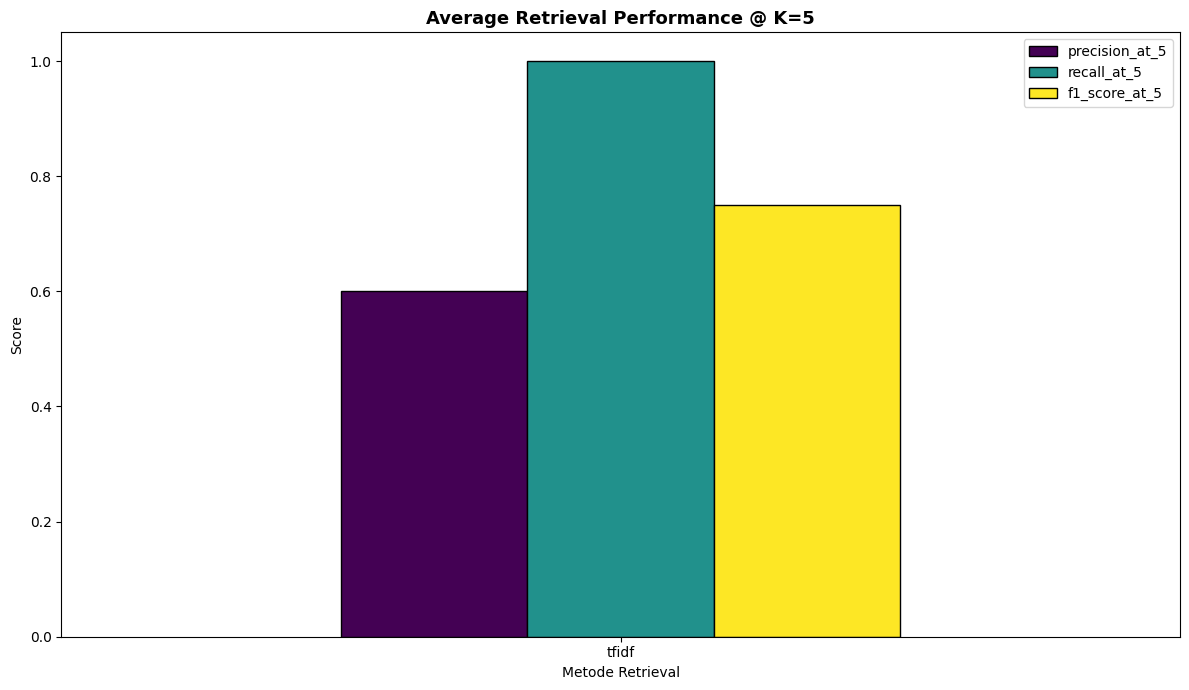

✅ Grafik retrieval disimpan ke: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/eval/retrieval_performance_chart.png


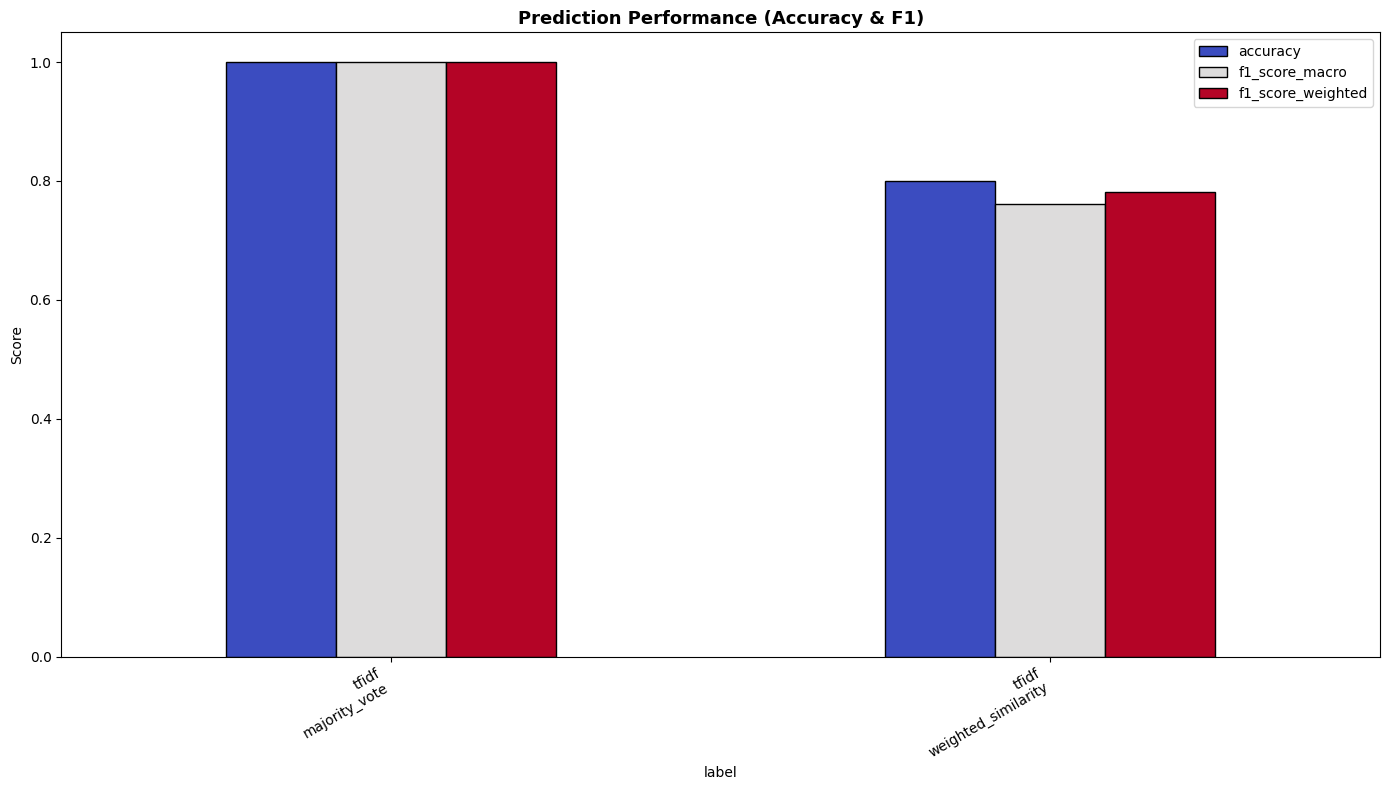

✅ Grafik prediksi disimpan ke: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/eval/prediction_performance_chart.png

--- Analisis Kegagalan (Panduan Manual) ---
1. Buka retrieval_metrics_per_query.csv → filter query dengan skor rendah.
2. Bandingkan top_k_case_ids yang di-retrieve dengan ground_truth_ids.
3. Kemungkinan penyebab: query ambigu, mismatch kosakata (TF-IDF),
   keterbatasan BERT, atau kualitas teks PDF (OCR error, boilerplate).
4. Solusi: perbaiki preprocessing, query expansion, atau fine-tune BERT.
TAHAP 5: Model Evaluation — SELESAI

Tahap 5: Model Evaluation - Complete.


In [37]:
# --- Eksekusi Utama ---
if __name__ == "__main__":
    log_cleaning_action("=" * 60)
    log_cleaning_action("TAHAP 5: Model Evaluation — MULAI")
    log_cleaning_action("=" * 60)
    print("Starting Tahap 5: Model Evaluation")
#     drive.mount('/content/drive', force_remount=True)

    if load_data_for_evaluation():
        df_avg_ret_metrics = evaluate_retrieval_performance()
        df_pred_metrics = evaluate_prediction_performance() # This might return empty if no ground_truth_solution
        visualize_and_analyze(df_avg_ret_metrics, df_pred_metrics)
    else:
        print("Failed to load necessary data. Evaluation cannot proceed.")

    log_cleaning_action("TAHAP 5: Model Evaluation — SELESAI")
    print("\nTahap 5: Model Evaluation - Complete.")